# Imports

In [3]:
import pandas as pd
import numpy as np
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.tree import DecisionTreeRegressor
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Loading Data

In [4]:
try:
    df_2023 = pd.read_csv('data2023.csv')
    df_2024 = pd.read_csv('data2024.csv')
except FileNotFoundError as e:
    print(f"Error loaidng the files: {e}")

combined_df = pd.concat([df_2023, df_2024], ignore_index=True)

print(f"Union complete succesfuly, total rows: {len(combined_df)}")

Union complete succesfuly, total rows: 26888


## Bacic Statistics

In [5]:
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26888 entries, 0 to 26887
Data columns (total 53 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   RouteID                      26888 non-null  int64  
 1   RouteName                    26888 non-null  int64  
 2   RouteDirection               26888 non-null  int64  
 3   AgencyName                   26888 non-null  object 
 4   ClusterName                  26888 non-null  object 
 5   Metropolin                   26888 non-null  object 
 6   OriginCityName               26888 non-null  object 
 7   DestinationCityName          26888 non-null  object 
 8   RouteType                    26888 non-null  object 
 9   ServiceType                  26871 non-null  object 
 10  RouteParticular              26888 non-null  object 
 11  BusType                      26871 non-null  object 
 12  BusSize                      26888 non-null  object 
 13  NumOfAlternative

In [6]:
combined_df.isnull().sum()

,0
RouteID,0
RouteName,0
RouteDirection,0
AgencyName,0
ClusterName,0
Metropolin,0
OriginCityName,0
DestinationCityName,0
RouteType,0
ServiceType,17


# Pre-Proccesing

In [7]:
# Define columns thresholds
min_non_null_records = 8000

# Calculate non-null counts for each column
non_null_counts = combined_df.notnull().sum()

# Identify columns to drop (those with less than min_non_null_records non-null entries)
columns_to_drop = non_null_counts[non_null_counts < min_non_null_records].index.tolist()

# Drop the identified columns from combined_df
if columns_to_drop:
    combined_df = combined_df.drop(columns=columns_to_drop)
    print(f"Dropped columns with less than {min_non_null_records} non-null records: {', '.join(columns_to_drop)}")
    print(f"New shape of combined_df: {combined_df.shape}")
else:
    print(f"No columns found with less than {min_non_null_records} non-null records.")


Dropped columns with less than 8000 non-null records: UniqueLocations, WorkDay - 00:00-03:59, Friday - 00:00-03:59, Friday - 04:00-05:59, Friday - 15:00-18:59, Friday - 19:00-23:59, Saturday - 00:00-03:59, Saturday - 04:00-05:59, Saturday - 06:00-08:59, Saturday - 09:00-11:59, Saturday - 12:00-14:59, Saturday - 15:00-18:59
New shape of combined_df: (26888, 41)


In [8]:
# Re-apply the initial column dropping from cell
min_non_null_columns_threshold = 8000
non_null_counts_initial = combined_df.notnull().sum()
columns_to_drop_initial = non_null_counts_initial[non_null_counts_initial < min_non_null_columns_threshold].index.tolist()
if columns_to_drop_initial:
    combined_df = combined_df.drop(columns=columns_to_drop_initial)
    print(f"Re-applied initial column drops. New shape: {combined_df.shape}")
else:
    print("No initial columns to drop found during regeneration.")

# Now, apply the new logic: drop rows if columns with over 18000 nulls contain NaN
null_counts = combined_df.isnull().sum()
columns_with_many_nulls = null_counts[null_counts > 18000].index.tolist()

if columns_with_many_nulls:
    initial_rows = combined_df.shape[0]
    combined_df.dropna(subset=columns_with_many_nulls, inplace=True)
    rows_dropped = initial_rows - combined_df.shape[0]
    print(f"Dropped {rows_dropped} rows with NaN values in columns: {', '.join(columns_with_many_nulls)}.")
    print(f"New shape of combined_df: {combined_df.shape}")
else:
    print("No columns found with more than 18000 null records to process for NaN values.")


No initial columns to drop found during regeneration.
Dropped 18106 rows with NaN values in columns: UniqueStations.
New shape of combined_df: (8782, 41)


In [9]:
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8782 entries, 1 to 26887
Data columns (total 41 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   RouteID                      8782 non-null   int64  
 1   RouteName                    8782 non-null   int64  
 2   RouteDirection               8782 non-null   int64  
 3   AgencyName                   8782 non-null   object 
 4   ClusterName                  8782 non-null   object 
 5   Metropolin                   8782 non-null   object 
 6   OriginCityName               8782 non-null   object 
 7   DestinationCityName          8782 non-null   object 
 8   RouteType                    8782 non-null   object 
 9   ServiceType                  8778 non-null   object 
 10  RouteParticular              8782 non-null   object 
 11  BusType                      8778 non-null   object 
 12  BusSize                      8782 non-null   object 
 13  NumOfAlternatives     

In [10]:
# Identify numerical and categorical columns
numerical_cols = combined_df.select_dtypes(include='float64').columns
numerical_cols_int = combined_df.select_dtypes(include='int64').columns
categorical_cols = combined_df.select_dtypes(include='object').columns

# Create copies for imputation to avoid modifying the original combined_df directly in place during this step
df_numerical = combined_df[numerical_cols].copy()
df_categorical = combined_df[categorical_cols].copy()
df_numerical_int = combined_df[numerical_cols_int].copy()

# Use Decision Tree Regressor model for missing values
imputer = IterativeImputer(
    estimator=DecisionTreeRegressor(random_state=42, max_depth=10), # המודל שילמד את הקשרים
    max_iter=10,  # מספר האיטרציות
    random_state=42
)
df_imputed_array = imputer.fit_transform(df_numerical)

# Return the data to Pandas structure
df_imputed_numerical = pd.DataFrame(df_imputed_array,
                                    columns=numerical_cols,
                                    index=combined_df.index)

# Combine continuos with categorical columns
df_imputed = pd.concat([df_numerical_int, df_imputed_numerical, df_categorical], axis=1)

השלמת הערכים הסתיימה בהצלחה.


/usr/local/lib/python3.12/dist-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


In [11]:
df_imputed.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8782 entries, 1 to 26887
Data columns (total 41 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   RouteID                      8782 non-null   int64  
 1   RouteName                    8782 non-null   int64  
 2   RouteDirection               8782 non-null   int64  
 3   NumOfAlternatives            8782 non-null   int64  
 4   StationsInRoute              8782 non-null   int64  
 5   DailyRides(Tuesday)          8782 non-null   int64  
 6   WeekyRides                   8782 non-null   int64  
 7   year                         8782 non-null   int64  
 8   Q                            8782 non-null   int64  
 9   RouteLength                  8782 non-null   float64
 10  WeeklyKM                     8782 non-null   float64
 11  AVGPassengersPerWeek         8782 non-null   float64
 12  UniqueStations               8782 non-null   float64
 13  AverageSpeed          

In [12]:
# Change data name
df = df_imputed.copy()

# Function to handle hebrew words in data with the plots
def fix_hebrew(text):
    if isinstance(text, str):
        return text[::-1]
    return text

# Plots

## Task 1

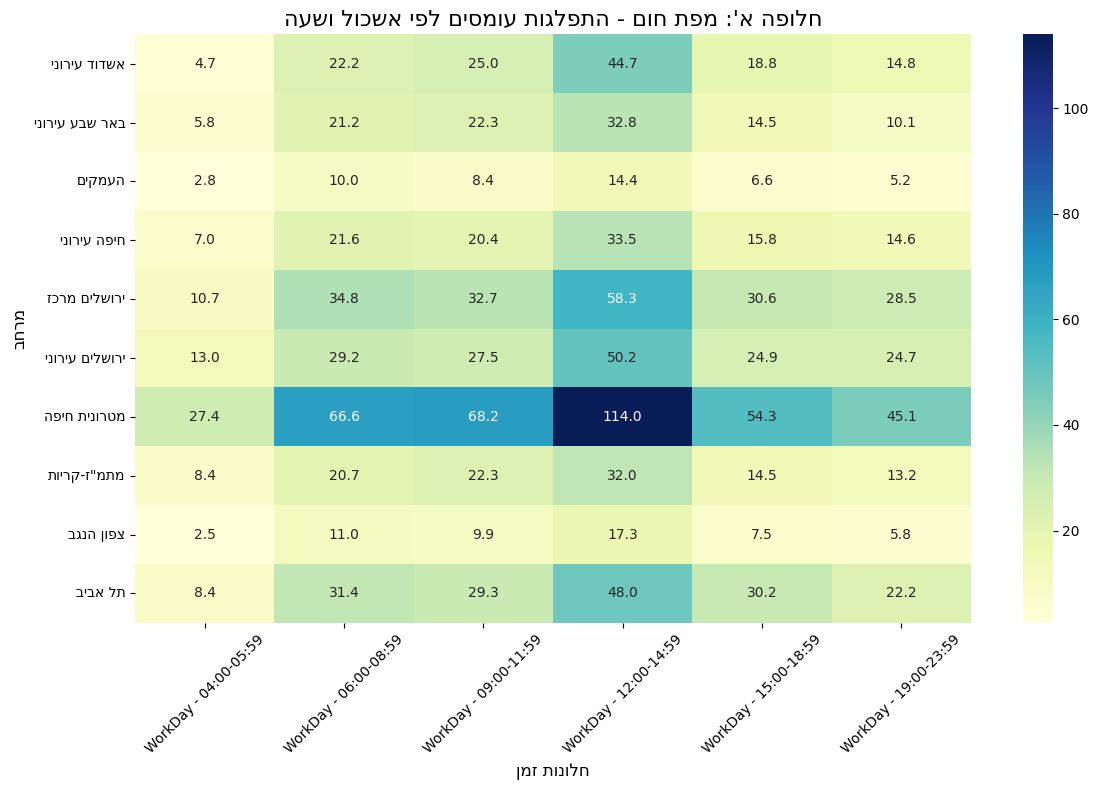

In [13]:
# Define Time columns
time_windows = [
    'WorkDay - 04:00-05:59',
    'WorkDay - 06:00-08:59', 'WorkDay - 09:00-11:59',
    'WorkDay - 12:00-14:59', 'WorkDay - 15:00-18:59',
    'WorkDay - 19:00-23:59'
]
# Aggregation
top_clusters = df.groupby('ClusterName')['WeeklyPassengers'].sum().nlargest(10).index
df_top = df[df['ClusterName'].isin(top_clusters)]
df_agg = df_top.groupby('ClusterName')[time_windows].mean()

# Fix hebrew columnms
df_agg.index = [fix_hebrew(x) for x in df_agg.index]

# Create heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df_agg, annot=True, cmap='YlGnBu', fmt='.1f')
# Define titles
plt.title(fix_hebrew("חלופה א': מפת חום - התפלגות עומסים לפי אשכול ושעה"), fontsize=16)
plt.xlabel(fix_hebrew('חלונות זמן'), fontsize=12)
plt.ylabel(fix_hebrew('מרחב'), fontsize=12)
# Plot the heatmap
plt.xticks(rotation=45)
plt.tight_layout()

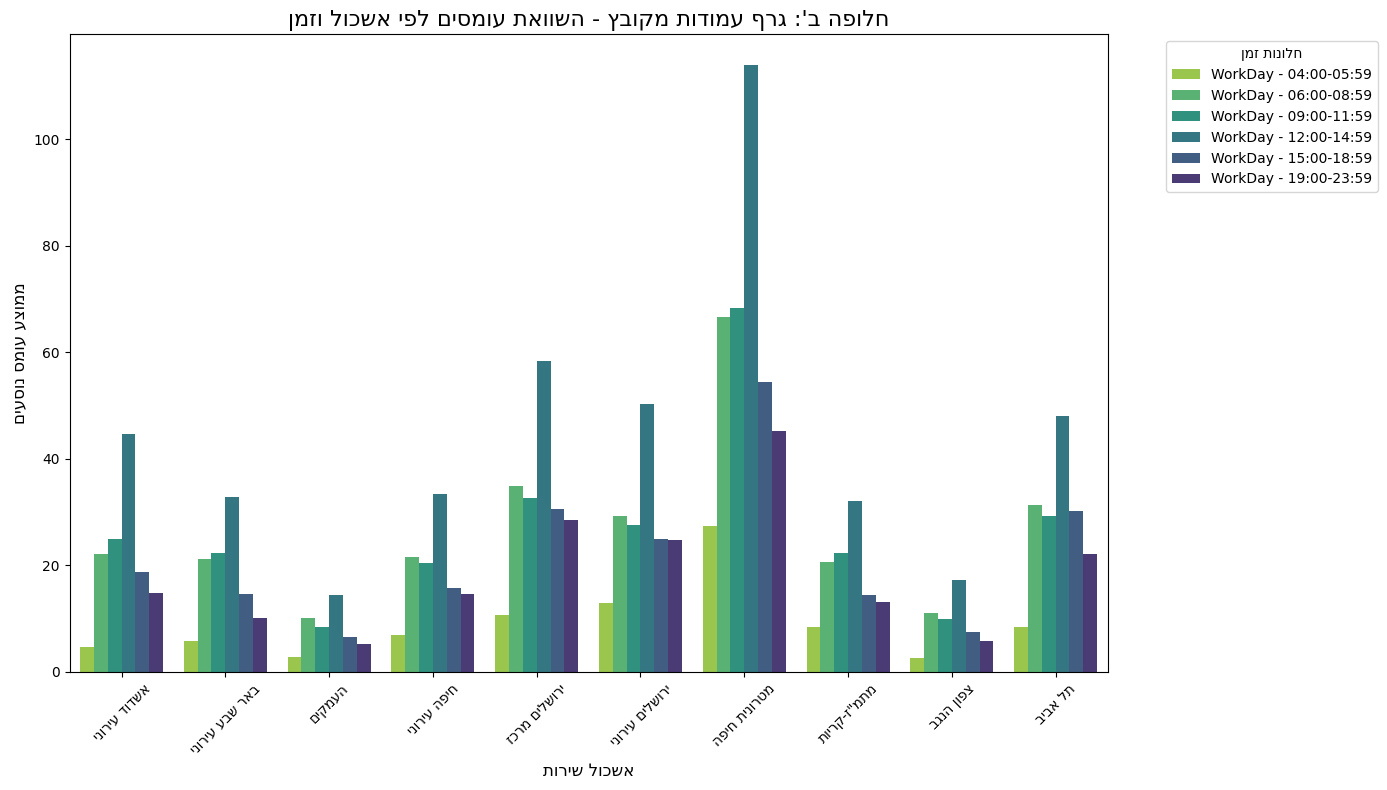

In [14]:
# Plot Grouped Bar Chart
df_long = df_agg.reset_index().rename(columns={'index': 'ClusterName'}).melt(id_vars='ClusterName', var_name='TimeWindow', value_name='AverageLoad')

plt.figure(figsize=(14, 8))
sns.barplot(data=df_long, x='ClusterName', y='AverageLoad', hue='TimeWindow', palette='viridis_r')
plt.title(fix_hebrew("חלופה ב': גרף עמודות מקובץ - השוואת עומסים לפי אשכול וזמן"), fontsize=16)
plt.xlabel(fix_hebrew('אשכול שירות'), fontsize=12)
plt.ylabel(fix_hebrew('ממוצע עומס נוסעים'), fontsize=12)
plt.legend(title=fix_hebrew('חלונות זמן'), bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()

## Task 2

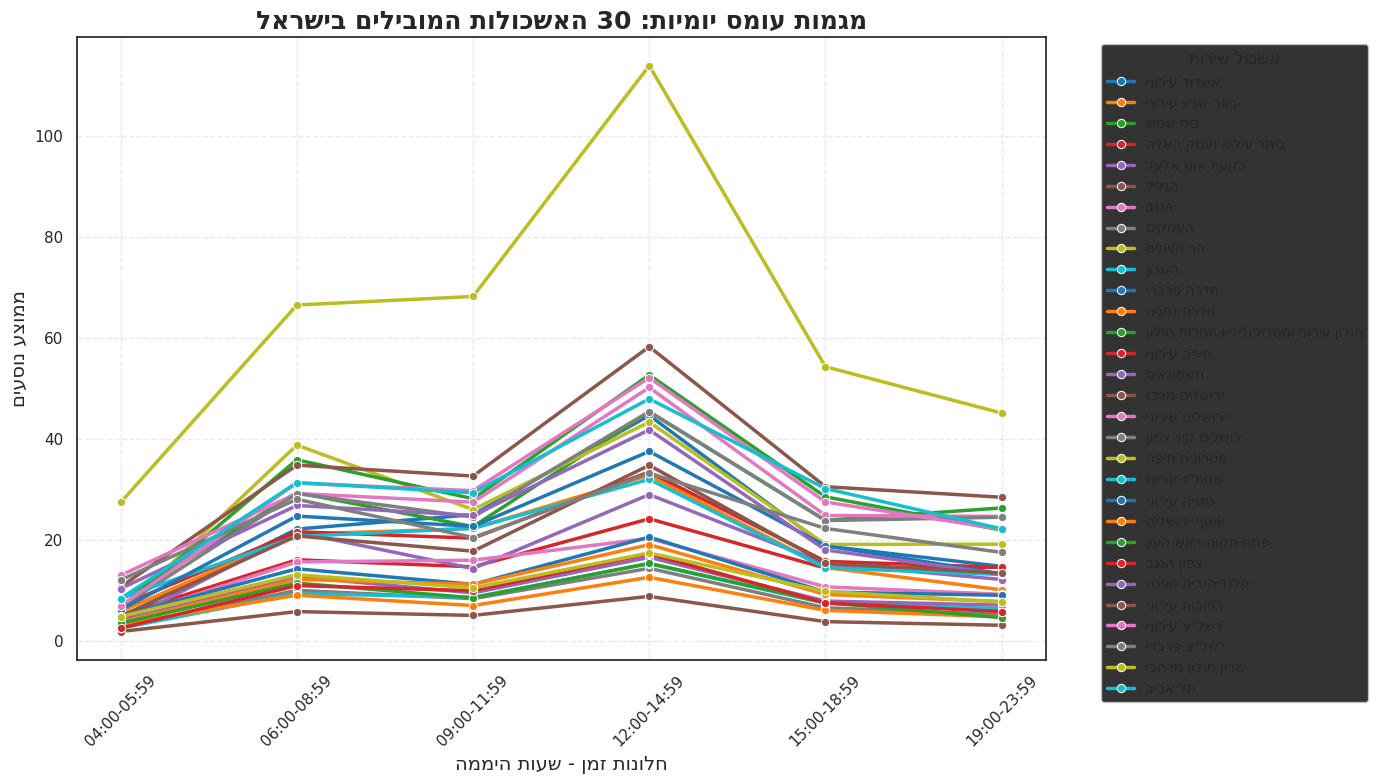

In [45]:
# Identify the top 30 most significant clusters
top_30_clusters = df.groupby('ClusterName')['WeeklyPassengers'].sum().nlargest(30).index

# Filter the original DataFrame to contain only these clusters
df_top = df[df['ClusterName'].isin(top_30_clusters)].copy()

# Fill missing values with 0
df_top[time_windows] = df_top[time_windows].fillna(0)

# Aggregation: average passengers per cluster for each time window
df_agg = df_top.groupby('ClusterName')[time_windows].mean().reset_index()

# Convert to long format for Seaborn
df_long = df_agg.melt(id_vars='ClusterName', value_vars=time_windows,
                         var_name='TimeWindow', value_name='Passengers')

# Clean time window names (show hours only) and fix Hebrew
df_long['TimeLabel'] = df_long['TimeWindow'].apply(lambda x: x.split('- ')[1])
df_long['Cluster_Fixed'] = df_long['ClusterName'].apply(fix_hebrew)

# Create the visualization (Line Chart)
plt.figure(figsize=(14, 8))
# Using a distinct color palette for 10 lines
sns.lineplot(data=df_long, x='TimeLabel', y='Passengers', hue='Cluster_Fixed',
             marker='o', linewidth=2.5, palette='tab10')

# Add labels and titles
plt.title(fix_hebrew("מגמות עומס יומיות: 03 האשכולות המובילים בישראל"), fontsize=18, fontweight='bold')
plt.xlabel(fix_hebrew("חלונות זמן - שעות היממה"), fontsize=14)
plt.ylabel(fix_hebrew("ממוצע נוסעים"), fontsize=14)

# Position the legend outside the graph so it doesn't obscure data
plt.legend(title=fix_hebrew("אשכול שירות"), bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)

plt.grid(True, linestyle='--', alpha=0.4)
plt.xticks(rotation=45)
plt.tight_layout()

/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)


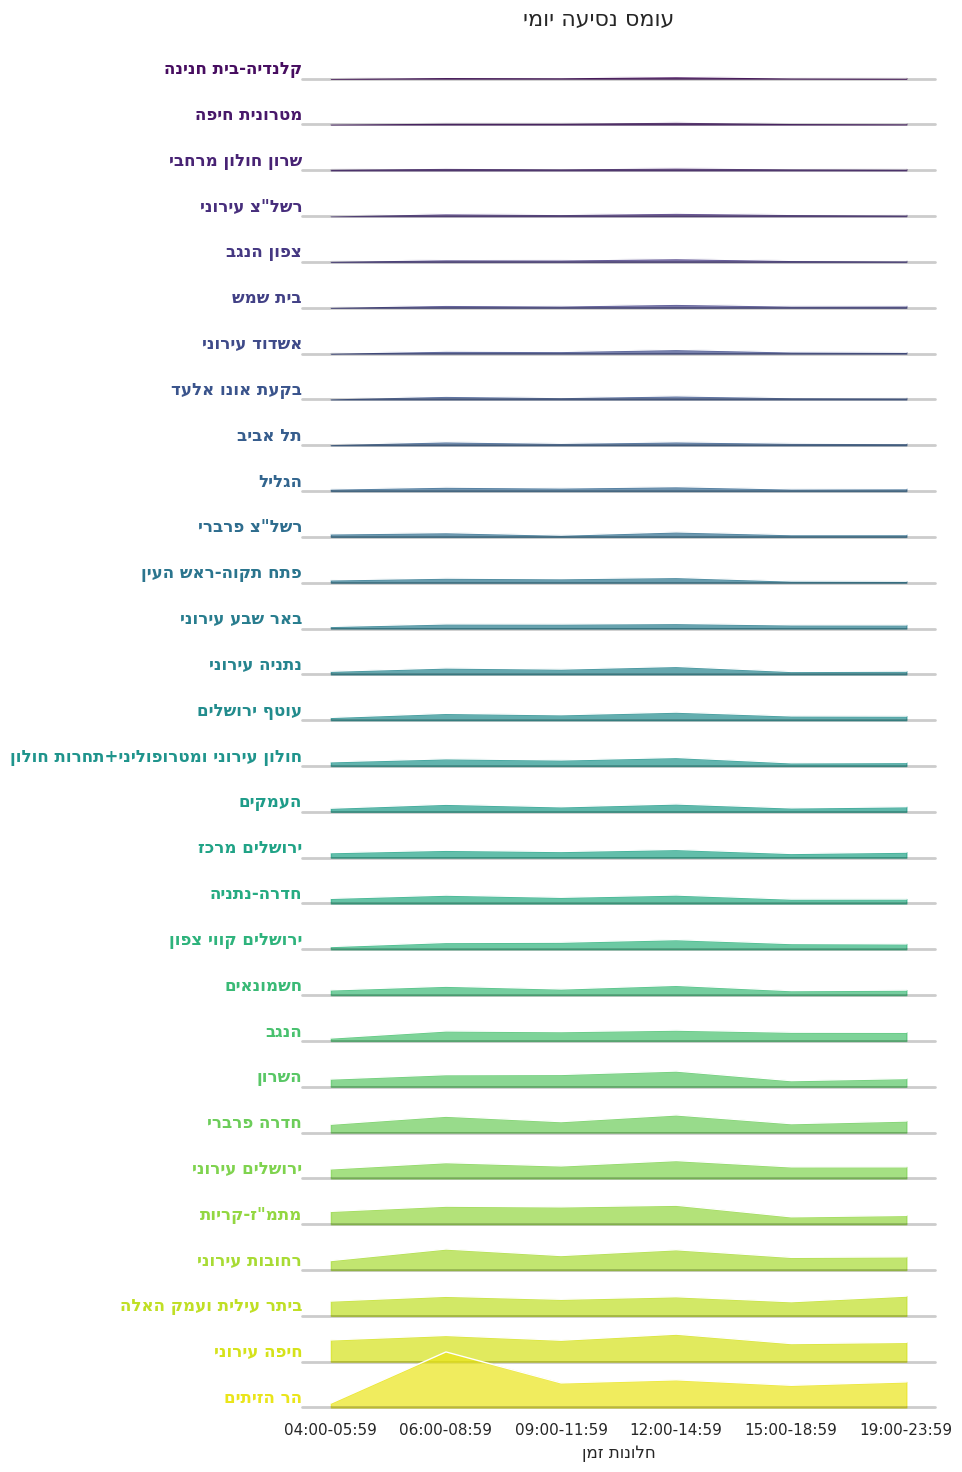

In [47]:
# 3. Normalization: Passengers per Kilometer
df_norm = df[df['WeeklyKM'] > 0].copy()
df_norm[time_windows] = df_norm[time_windows].fillna(0)
for col in time_windows:
    df_norm[col] = df_norm[col] / df_norm['WeeklyKM']

# Select the top 30 clusters
top_30_clusters = df.groupby('ClusterName')['WeeklyPassengers'].sum().nlargest(30).index
df_top = df_norm[df_norm['ClusterName'].isin(top_30_clusters)].copy()

# Aggregation and conversion to long format
df_agg = df_top.groupby('ClusterName')[time_windows].mean().reset_index()
df_long = df_agg.melt(id_vars='ClusterName', value_vars=time_windows,
                         var_name='TimeWindow', value_name='Efficiency')

df_long['TimeLabel'] = df_long['TimeWindow'].apply(lambda x: x.split('- ')[1])
df_long['Cluster_Fixed'] = df_long['ClusterName'].apply(fix_hebrew)

# Calculate the total efficiency for each cluster to sort them
cluster_order = df_long.groupby('Cluster_Fixed')['Efficiency'].sum().sort_values(ascending=True).index

# Convert 'Cluster_Fixed' to a categorical type with the desired order
df_long['Cluster_Fixed'] = pd.Categorical(df_long['Cluster_Fixed'], categories=cluster_order, ordered=True)

# Create a Ridgeline-style plot using FacetGrid
sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})

# Create the matrix - small height for each graph to create a ridgeline effect
g = sns.FacetGrid(df_long, row="Cluster_Fixed", hue="Cluster_Fixed", aspect=15, height=.5, palette="viridis")

# Draw the filled areas (ridgelines)
g.map(plt.fill_between, "TimeLabel", "Efficiency", alpha=0.7)
g.map(plt.plot, "TimeLabel", "Efficiency", color="white", lw=1)

# Add a baseline to each ridgeline
g.map(plt.axhline, y=0, lw=2, clip_on=False, color='black', alpha=0.2)

# Set titles for each ridgeline on the side
def label(x, color, label):
    ax = plt.gca()
    ax.text(0, .2, label, fontweight="bold", color=color,
            ha="right", va="center", transform=ax.transAxes)

g.map(label, "Cluster_Fixed")

# Remove default titles and arrange axes
g.set_titles("")
g.set(yticks=[], ylabel="")
g.despine(bottom=True, left=True)

plt.subplots_adjust(hspace=-0.25) # Tighten the ridgelines
g.set_xlabels(fix_hebrew("חלונות זמן"))
plt.suptitle(fix_hebrew("עומס נסיעה יומי"), y=0.98, fontsize=16)

plt.savefig('ridgeline_efficiency.png')
plt.show()

## Task 3

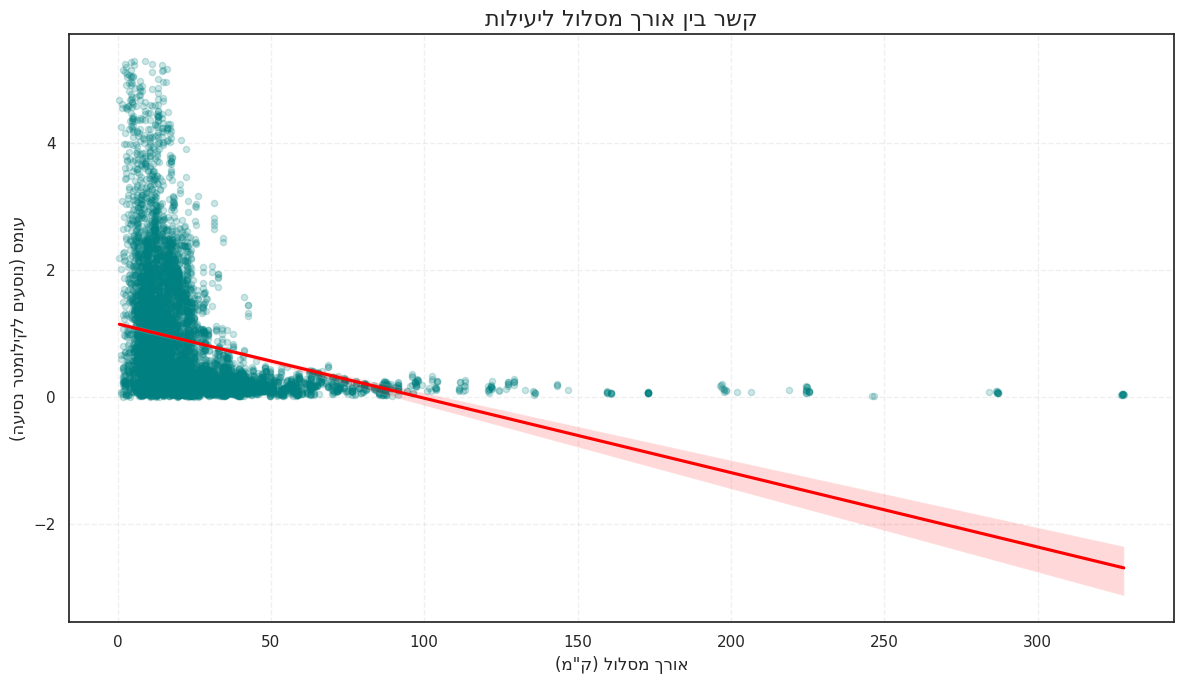

In [50]:
# Calculate Efficiency Index
df['Efficiency'] = df['WeeklyPassengers'] / df['WeeklyKM']

# Calculate the 99th percentile. Any value above it will be considered an anomaly that stretches the graph.
upper_limit = df['Efficiency'].quantile(0.99)
df_filtered = df[df['Efficiency'] <= upper_limit].copy()

# Create the scatter plot without anomalies
plt.figure(figsize=(12, 7))

# Use regplot on the filtered data
sns.regplot(data=df_filtered, x='RouteLength', y='Efficiency',
            scatter_kws={'alpha':0.2, 'color':'teal', 's':20},
            line_kws={'color':'red'})

# Labels and Titles
plt.title(fix_hebrew(f"קשר בין אורך מסלול ליעילות"), fontsize=16)
plt.xlabel(fix_hebrew("אורך מסלול )ק\"מ("), fontsize=12)
plt.ylabel(fix_hebrew("עומס )נוסעים לקילומטר נסיעה("), fontsize=12)

plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

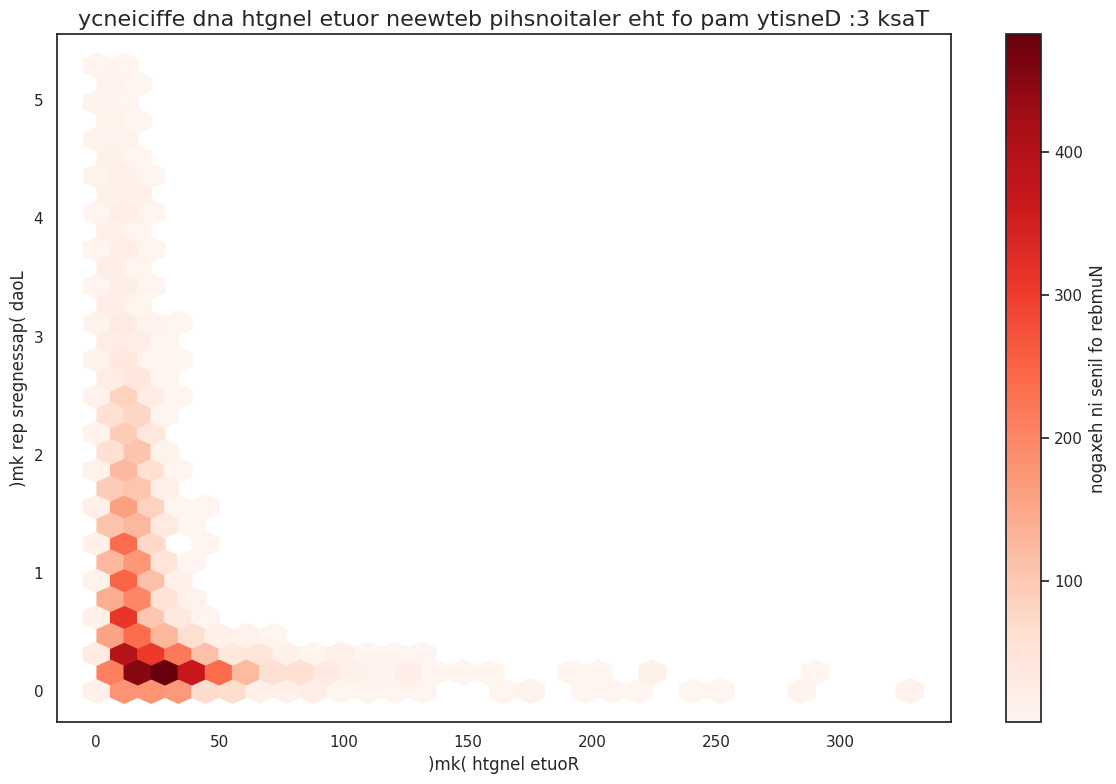

In [51]:
# Create Hexbin plot
plt.figure(figsize=(12, 8))

# matplotlib's hexbin function
hb = plt.hexbin(
    df_filtered['RouteLength'],
    df_filtered['Efficiency'],
    gridsize=30,
    cmap='Reds',
    mincnt=1
)

# Add color bar (Legend)
cb = plt.colorbar(hb)
cb.set_label(fix_hebrew('Number of lines in hexagon'))

# Styling and Hebrew correction
plt.title(fix_hebrew("Task 3: Density map of the relationship between route length and efficiency"), fontsize=16)
plt.xlabel(fix_hebrew("Route length (km)"), fontsize=12)
plt.ylabel(fix_hebrew("Load (passengers per km)"), fontsize=12)

plt.tight_layout()
plt.savefig('task3_hexbin_plot.png')
plt.show()